# Learned embeddings against CellProfiler

[JUMP-Lite](../../datasets/jump_lite.ipynb) {cite:p}`Munoz_2026` measured the same 1,536 wells six ways: four
learned embeddings, the same architecture as one of them with untrained weights, and `cp_measure`, a
CellProfiler-equivalent feature set. Swapping the feature block is a controlled experiment rather than a change
of dataset. The images are lossy and there is one field of view per well, and the dataset page says what that
bounds. [Bringing your own embedding](../data/embeddings.ipynb) covers loading one and what `var` no longer
tells you.

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

import mantispy as mt

classical = mt.ds.jump_lite("cp_measure")
mt.pp.normalize(classical, method="mad_robustize", by="Metadata_Plate", reference="negcon")

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/ETcli4Pw/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_93693/2287270834.py:10: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(classical, method="mad_robustize", by="Metadata_Plate", reference="negcon")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_93693/2287270834.py:10: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 

## Preparing each block

The embeddings are normalized per plate and not selected, for the reason on
[Bringing your own embedding](../data/embeddings.ipynb). `cp_measure` is a list of measurements, with the usual
pathologies: features that never vary, that duplicate each other, or that run away to enormous values. Holding
the selection identical across blocks would be the unfair comparison, not the fair one. Here is what each
selection step is worth on it.

In [2]:
PYCYTOMINER = ("variance_threshold", "correlation_threshold", "drop_na_columns", "blocklist")
# feature_select's own default: drop_degenerate, which removes only what normalize flagged, then pycytominer's.
DEFAULT = ("drop_degenerate", *PYCYTOMINER)

selection = {}
for label, operations in {
    "none": ("drop_degenerate", "drop_na_columns"),
    "pycytominer default": DEFAULT,
    "default + drop_outliers": (*DEFAULT, "drop_outliers"),
    "+ noise_removal": (*DEFAULT, "drop_outliers", "noise_removal"),
}.items():
    trial = classical.copy()
    mt.pp.feature_select(trial, operations=operations, na_cutoff=0.0)
    trial = mt.pp.subset_features(trial)
    selection[label] = {
        "features": trial.n_vars,
        "largest |value|": float(np.abs(np.asarray(trial.X)).max()) if trial.n_vars else np.nan,
    }
pd.DataFrame(selection).T

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_93693/1604515389.py:13: UserWarning: feature_select flagged none of the 2550 features as selected; uns['mantispy']['feature_select'] says what each operation removed. Every cutoff here is an absolute threshold on the scale pp.normalize left the values on, so check it against that scale; noise_removal's stdev_cutoff is the usual cause.
  mt.pp.feature_select(trial, operations=operations, na_cutoff=0.0)


,features,largest |value|
none,1949.0,178622.234375
pycytominer default,540.0,178622.234375
default + drop_outliers,526.0,456.745605
+ noise_removal,0.0,NaN


Left alone, `cp_measure` carries values of order 1e5, which survive a robust per-plate normalization because
they are not constant, merely enormous. The pycytominer default cuts the block to about a quarter of its
features and leaves the largest value where it was. `drop_outliers`, which is in `pp.OPERATIONS` and not in the
default set, removes only fourteen more features and brings the largest value down about four-hundred-fold.
`noise_removal` empties the block: its cutoff is an absolute standard deviation, and on the scale
`mad_robustize` leaves no feature falls under it.

So `cp_measure` gets the standard selection plus `drop_outliers`, and the embeddings get none.

## Comparing six feature sets

The question is not whether an embedding works, but how it compares with the alternatives on the same wells.
Two readouts:

- **`tl.map`** — mean average precision. Rank every other profile by similarity to a query and ask whether
  its replicates come first. The pairs are defined so that a replicate must come from a *different
  laboratory*, which is the cross-site reproducibility question, and copairs gives every compound a
  permutation p-value that is then BH-corrected. This is the metric the JUMP benchmarks report
  {cite:p}`Kalinin_2025,Arevalo_2024`, and it is the only one of the two that scales: the
  similarity-matrix readouts build a dense n-by-n matrix and stop at about 22,000 profiles.
- **`metrics.known_relationships`** — of the compounds annotated to act on the same gene, how many end up in
  either tail of the similarity distribution?

Each is measured under three alignments: the principal components alone, `pp.tvn`, and `pp.harmony`, which
ranked top-three in every scenario of the batch-correction benchmark {cite:p}`Arevalo_2024` and is the last
step of the JUMP recipe. `pp.harmony` needs the optional extra, `pip install 'mantispy[harmony]'`.

In [3]:
targets = mt.ds.jump_lite_targets()


def align(wells):
    """The three alignments every block is compared under: none, TVN and Harmony, on the same 50 components."""
    sc.pp.pca(wells, n_comps=50)
    mt.pp.tvn(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_tvn")
    mt.pp.harmony(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_harmony")
    return wells


def prepared(model):
    """Load one feature set and align it three ways.

    The CellProfiler block gets the standard selection; the embeddings get none, for the reason above.
    """
    wells = mt.ds.jump_lite(model)
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    operations = (*DEFAULT, "drop_outliers") if model == "cp_measure" else ("drop_degenerate", "drop_na_columns")
    mt.pp.feature_select(wells, operations=operations, na_cutoff=0.0)
    return align(mt.pp.subset_features(wells))


def treated_profiles(wells, rep):
    """One alignment of the treated wells, as an object the metrics can score."""
    treated = ~wells.obs["Metadata_Control"].to_numpy()
    profiles = ad.AnnData(np.asarray(wells.obsm[rep], dtype=np.float32)[treated], obs=wells.obs[treated].copy())
    mt.io.stamp(profiles, resolution="well")
    return profiles


blocks = {model: prepared(model) for model in mt.ds.JUMP_LITE_MODELS}
{model: wells.n_vars for model, wells in blocks.items()}

/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_93693/2337959602.py:18: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_93693/2337959602.py:18: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to t

{'openphenom': 384,
 'dinov2': 384,
 'dinov2_random': 384,
 'subcell': 1536,
 'morphem': 1920,
 'cp_measure': 526}

In [4]:
CROSS_LAB = {
    "pos_sameby": ["Metadata_Perturbation"],
    "pos_diffby": ["Metadata_Source"],  # a replicate pair has to cross laboratories
    "neg_diffby": ["Metadata_Perturbation"],
}
scored_profiles = {}


def scored(name, wells, rep):
    """Cross-laboratory mAP on wells, and target recall on consensus profiles against its own null."""
    profiles = treated_profiles(wells, rep)
    mt.tl.map(profiles, **CROSS_LAB, null_size=10_000)  # the default; the note under the table says why not fewer
    per_compound = profiles.uns["mantispy"]["map"]
    scored_profiles[name, rep] = profiles  # kept so the per-compound panels below need not score again

    consensus = mt.tl.consensus(profiles, method="median", min_replicates=1)
    # Chance is measured, not assumed to be 10%; the section on chance below says why.
    recall = mt.metrics.known_relationships(consensus, targets, n_permutations=100, seed=0).iloc[0]
    return {
        "mAP": float(per_compound["mean_average_precision"].mean()),
        "significant": int(per_compound["below_corrected_p"].sum()),
        "target recall": float(recall["value"]),
        "recall null": float(recall["null"]),
        "recall p": float(recall["p_value"]),
        "source variance": float(mt.metrics.pc_regression(wells, key="Metadata_Source", use_rep=rep)["value"].iloc[0]),
    }


comparison = pd.DataFrame(
    [
        {"model": model, "alignment": rep, **scored(model, wells, rep)}
        for model, wells in blocks.items()
        for rep in ("X_pca", "X_tvn", "X_harmony")
    ]
)
comparison.pivot(index="model", columns="alignment", values=["mAP", "significant"]).round(3)

mAP               significant            
alignment     X_harmony  X_pca  X_tvn   X_harmony X_pca X_tvn
model                                                        
cp_measure        0.074  0.050  0.026       106.0  32.0   4.0
dinov2            0.068  0.031  0.029        75.0   5.0   5.0
dinov2_random     0.010  0.009  0.010         0.0   0.0   0.0
morphem           0.087  0.027  0.035        93.0   3.0   6.0
openphenom        0.037  0.016  0.018         4.0   0.0   3.0
subcell           0.075  0.027  0.022        73.0   2.0   2.0

`significant` counts the compounds whose mAP survives a BH correction over the 301 tested, which is the number
a screener cares about: how many compounds would you have called. It needs a large permutation null. copairs
cannot return a p-value below one over the number of draws plus one, and `tl.map` warns when the null is too
small for the correction to call anything, so keep the default of 10,000 draws.

Four things to read out of the comparison table.

**The untrained model behaves like one.** `dinov2_random` is the same architecture with random weights, and
it is the control for the whole comparison. Its mAP sits at the floor under every alignment, because random
projections of an image do not reproduce across laboratories, and no correction manufactures structure out of
noise. Every other block beats it on mAP under every alignment, which is the least a pipeline has to show.

**Uncorrected, the classical block reproduces and the embeddings barely do.** Look at the `X_pca` column of
`significant`: `cp_measure` calls 32 of the 301 compounds across laboratories with no batch correction at all,
and the learned embeddings call between none and five. After `pp.harmony` four of the blocks call 73 to 106;
`openphenom` calls four. The embeddings need the correction to reproduce across sites much more than the
named measurements do.

**Alignment matters as much as the choice of model.** `pp.harmony` lifts the mAP of every block but the
untrained one, by 1.5 to 3.2 times. Under Harmony, the choice of block then moves it again by more
than a factor of two, and the number of compounds called from four to 106. `pp.tvn` does little for
retrieval: no block calls more than six compounds under it. It adds a few on MorphEm and OpenPhenom, and on
`cp_measure` it cuts the 32 uncorrected calls to four. Neither the model nor the correction is the
small decision.

**The CellProfiler-equivalent set leads without a correction.** `cp_measure` tops the uncorrected column
and calls the most compounds under Harmony — though MorphEm's mean mAP under Harmony is higher, SubCell's and
DINOv2's are level with it, and under TVN `cp_measure` falls behind MorphEm and DINOv2.

Each of those compounds had to be told apart from *other compounds*, across laboratories. The JUMP-Lite
benchmark {cite:p}`Munoz_2026` also scores an easier question, phenotypic activity: do a compound's replicates
stand apart from the negative controls on the query's own plate? `tl.map` computes it with
`mode="activity"`, which keeps the controls in and retrieves against the ones plated beside each query.

In [5]:
def activity(wells, rep):
    """Phenotypic activity: do a compound's replicates retrieve each other against the controls on their plate?"""
    table = mt.tl.map(wells, mode="activity", use_rep=rep, copy=True).uns["mantispy"]["map"]
    return {
        "activity mAP": float(table["mean_average_precision"].mean()),
        "active": int(table["below_corrected_p"].sum()),
    }


activities = pd.DataFrame(
    [
        {"model": model, "alignment": rep, **activity(wells, rep)}
        for model, wells in blocks.items()
        for rep in ("X_pca", "X_tvn", "X_harmony")
    ]
)
activities.pivot(index="model", columns="alignment", values=["activity mAP", "active"]).round(3)

activity mAP                  active             
alignment        X_harmony  X_pca  X_tvn X_harmony X_pca  X_tvn
model                                                          
cp_measure           0.333  0.301  0.302      97.0  88.0   78.0
dinov2               0.317  0.275  0.327      92.0  78.0   99.0
dinov2_random        0.129  0.114  0.157       2.0   2.0    2.0
morphem              0.318  0.269  0.345      98.0  81.0  106.0
openphenom           0.293  0.251  0.267      88.0  70.0   83.0
subcell              0.306  0.261  0.290      89.0  77.0   84.0

On activity the blocks are close. `cp_measure` leads without a correction and on mean mAP under Harmony;
MorphEm leads under TVN and is level with it on the count under Harmony; DINOv2 is near both. Under TVN every
trained embedding calls more compounds active than `cp_measure` does. OpenPhenom has the lowest mean mAP of
the five real blocks under every alignment, and the untrained model calls two compounds under every alignment.

For nearly every compound, every replicate sits at another laboratory, so both readouts ask a query to find
replicates run elsewhere; what changes is what they have to outrank. Without a batch correction the learned
embeddings tell a compound from DMSO nearly as well as the named measurements do, 70 to 81 compounds active
against 88 for `cp_measure`, and have much more trouble telling one compound from another, where they call
five at most against its 32. Harmony narrows that: MorphEm, SubCell and DINOv2 then reach a cross-laboratory
mAP of 0.087, 0.075 and 0.068 against `cp_measure`'s 0.074, and call 73 to 93 compounds against its 106. That
is what you would see if these embeddings carry more of the laboratory than `cp_measure` does, and their
uncorrected source variance further down (about 0.03 to 0.04, against 0.02) points the same way. OpenPhenom is
the exception: it calls four even after Harmony.

The embeddings are used out of the box, without fine-tuning to Cell Painting data, on lossy-compressed JUMP
images with one fixed preprocessing. Treat the ranking as a property of this setup, not of the models.

### How much of the Harmony column is the seed

`pp.harmony` clusters the wells before it corrects them, and the clustering starts from a random draw, so the
seed moves the result, and so does the order of the rows, which the draw is taken over. The tables above are
one run each. Here is every block under five seeds.

In [6]:
spread = []
for model, wells in blocks.items():
    for seed in range(5):
        mt.pp.harmony(wells, batch_key="Metadata_Source", use_rep="X_pca", key_added="X_harmony_seed", seed=seed)
        profiles = treated_profiles(wells, "X_harmony_seed")
        mt.tl.map(profiles, **CROSS_LAB)
        spread.append(
            {
                "model": model,
                "cross-laboratory mAP": float(profiles.uns["mantispy"]["map"]["mean_average_precision"].mean()),
                "cross-laboratory calls": int(profiles.uns["mantispy"]["map"]["below_corrected_p"].sum()),
                **activity(wells, "X_harmony_seed"),
            }
        )
pd.DataFrame(spread).groupby("model").agg(["min", "max"]).round(3)

cross-laboratory mAP        cross-laboratory calls       \
                               min    max                    min  max   
model                                                                   
cp_measure                   0.073  0.079                     96  106   
dinov2                       0.068  0.077                     69   76   
dinov2_random                0.010  0.011                      0    0   
morphem                      0.085  0.087                     90   95   
openphenom                   0.037  0.040                      2    8   
subcell                      0.074  0.077                     68   73   

              activity mAP        active       
                       min    max    min  max  
model                                          
cp_measure           0.331  0.339     97  101  
dinov2               0.317  0.322     92   94  
dinov2_random        0.127  0.131      1    2  
morphem              0.318  0.320     97   98  
openphenom           0.293  0.296     88   91  
subcell              0.302  0.307     87   91

Five seeds move `cp_measure` between 96 and 106 compounds called across laboratories, MorphEm between 90 and
95, DINOv2 and SubCell between 68 and 76, and OpenPhenom between two and eight; the untrained model calls
none under any of them. The three tiers of calls survive every seed: `cp_measure` and MorphEm above DINOv2 and SubCell,
OpenPhenom far below. So does the order inside the first tier: `cp_measure` calls more compounds than MorphEm
under every seed, and MorphEm has the higher cross-laboratory mAP under every seed. What does not survive is a
gap of a few compounds, or of a few thousandths of mAP, between two blocks in one run: DINOv2 and SubCell
overlap on both, and on the activity count so do `cp_measure` and MorphEm, at 97 to 101 compounds active against 97 to
98. Read the Harmony column as a range, and compare two pipelines under Harmony over several seeds rather
than one.

### One preprocessing choice moves the CellProfiler result

JUMP-Lite's CellProfiler preparation includes a rank-based inverse normal transform {cite:p}`Munoz_2026`,
which this page leaves out; `pp.rank_int` computes it. It makes every feature's distribution the same shape,
which can matter a great deal for a block of measurements on wildly different scales. Here is `cp_measure`
both ways. The correlation filter then runs on the transformed values, so a somewhat different set of features
survives, and the table says how many.

In [7]:
def with_rank_int():
    """cp_measure prepared in the benchmark's order: the rank transform before the correlation filter."""
    wells = classical.copy()
    mt.pp.feature_select(
        wells, operations=("drop_degenerate", "drop_na_columns", "variance_threshold", "drop_outliers"), na_cutoff=0.0
    )
    wells = mt.pp.subset_features(wells)
    mt.pp.rank_int(wells, by="Metadata_Plate", stochastic=False)
    mt.pp.feature_select(wells, operations=("correlation_threshold", "blocklist"))
    return align(mt.pp.subset_features(wells))


ranked = with_rank_int()
recipes = pd.concat(
    [
        comparison.merge(activities)
        .query("model == 'cp_measure' and alignment != 'X_tvn'")
        .assign(recipe="as above", features=blocks["cp_measure"].n_vars),
        pd.DataFrame(
            [
                {"alignment": rep, **scored("cp_measure, with rank INT", ranked, rep), **activity(ranked, rep)}
                for rep in ("X_pca", "X_harmony")
            ]
        ).assign(recipe="with rank INT", features=ranked.n_vars),
    ]
)
recipes.set_index(["recipe", "alignment"])[
    ["features", "significant", "target recall", "recall null", "recall p", "activity mAP", "active"]
].rename(columns={"significant": "cross-laboratory calls"}).round(3)

features  cross-laboratory calls  target recall  \
recipe        alignment                                                    
as above      X_pca           526                      32          0.089   
              X_harmony       526                     106          0.077   
with rank INT X_pca           603                      19          0.164   
              X_harmony       603                      50          0.149   

                         recall null  recall p  activity mAP  active  
recipe        alignment                                               
as above      X_pca            0.051      0.01         0.301      88  
              X_harmony        0.052      0.01         0.333      97  
with rank INT X_pca            0.112      0.01         0.283      84  
              X_harmony        0.115      0.01         0.299      80

The transform cuts `cp_measure`'s cross-laboratory calls from 32 to 19 uncorrected and from 106 to 50 under
Harmony. Its raw annotation recall roughly doubles, but so does its null, so the gain over chance is modest:
the margin grows from 0.038 to 0.052 uncorrected and from 0.025 to 0.034 under Harmony. It is the trap the
section on chance below warns about: a raw recall that looks better mostly because its null rose with it. Its
effect on activity
depends on the alignment: small uncorrected, and under Harmony enough to drop `cp_measure` from first to fourth
of the five real blocks on activity mAP, behind MorphEm, DINOv2 and SubCell, and from level with MorphEm at the
top of the count to last. Under Harmony it also leaves `cp_measure` calling fewer
compounds across laboratories than MorphEm, DINOv2 or SubCell. So where the CellProfiler block ranks against
the embeddings here depends on a preprocessing step, not only on the features. The tables above keep this
page's recipe; this one is the reason not to read their `cp_measure` row as the CellProfiler result.

### What is chance, really?

`metrics.known_relationships` counts annotated pairs falling in either tail of the similarity distribution,
and a fixed tail width invites the assumption that a map with no information scores 10%. Here it does not.
The tails hold 10% of all pairs, so pairs drawn at random would land there 10% of the time. The annotated
pairs are not drawn at random: RefChemDB links some compounds to hundreds of genes and most to a few, so a
handful of compounds make up many of the pairs, and chance moves with where each representation puts those
few. So the chance level has to be measured. `n_permutations` shuffles which compound each annotation row
names, keeping every gene's number of compounds and every compound's number of genes, and reports the mean
recall over the shuffles as `null` and the share of shuffles that recall at least as much as `p_value`.

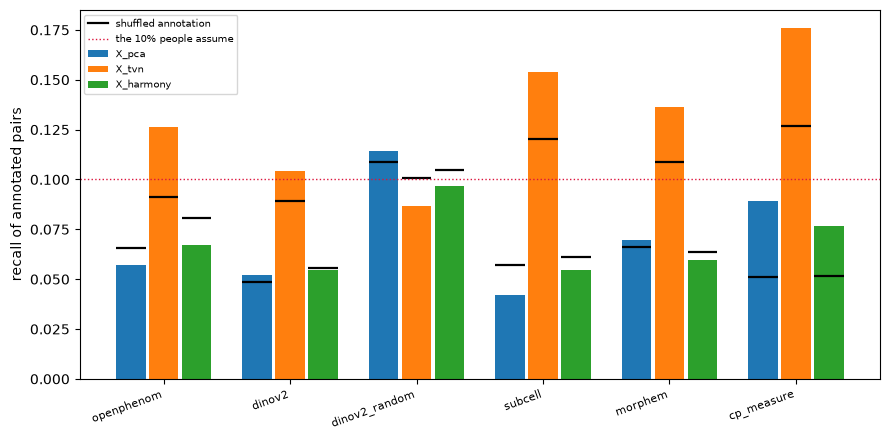

target recall               recall null                recall p  \
alignment         X_harmony  X_pca  X_tvn   X_harmony  X_pca  X_tvn X_harmony   
model                                                                           
cp_measure            0.077  0.089  0.176       0.052  0.051  0.127     0.010   
dinov2                0.055  0.052  0.104       0.055  0.049  0.089     0.564   
dinov2_random         0.097  0.114  0.087       0.105  0.109  0.101     0.812   
morphem               0.060  0.069  0.136       0.064  0.066  0.109     0.673   
openphenom            0.067  0.057  0.127       0.081  0.066  0.091     0.970   
subcell               0.055  0.042  0.154       0.061  0.057  0.120     0.812   

                             
alignment      X_pca  X_tvn  
model                        
cp_measure     0.010  0.010  
dinov2         0.307  0.059  
dinov2_random  0.248  0.980  
morphem        0.356  0.010  
openphenom     0.851  0.010  
subcell        0.990  0.010

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = list(blocks)
width = 0.26
for offset, alignment in zip((-width, 0, width), ("X_pca", "X_tvn", "X_harmony"), strict=True):
    block = comparison[comparison["alignment"] == alignment].set_index("model").loc[order]
    x = np.arange(len(order)) + offset
    ax.bar(x, block["target recall"], width * 0.9, label=alignment)
    # the shuffled-annotation level for this exact representation
    ax.hlines(block["recall null"], x - width * 0.45, x + width * 0.45, color="black", lw=1.6)
ax.plot([], [], color="black", lw=1.6, label="shuffled annotation")
ax.axhline(0.10, color="crimson", ls=":", lw=1, label="the 10% people assume")
ax.set_xticks(np.arange(len(order)), order, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("recall of annotated pairs")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

comparison.pivot(index="model", columns="alignment", values=["target recall", "recall null", "recall p"]).round(3)

The black bars are chance for that representation, and they are not a constant 10%: for the trained embeddings and
`cp_measure` they run from 5 to 8% without TVN and 9 to 13% with it, and for the untrained model they sit at
10 to 11% under every alignment. Read every recall against the bar sitting on it, not
against the red line.

Once you do, the readout says something clean, and something different from what the raw numbers suggest.
**`pp.tvn` lifts recall clearly above its own null on three of the four trained embeddings and on
`cp_measure`, and on DINOv2 only marginally (p = 0.06, five of the 100 shuffles scoring as high).
Under either of the other two alignments no embedding clears its own null — but `cp_measure` clears it under
all three.** And the
untrained model never clears it: its apparently high raw recall, the highest in the unaligned column, is
entirely a property of its null, which is high because a near-random projection spreads pairs into the tails.
That is exactly the trap a fixed baseline sets: in the unaligned and Harmony columns it would have made the
untrained control look like the best model on the page.

The shuffled annotation is what exposed the fixed baseline; the untrained model is where it would have done
the most damage. Keeping one in the comparison is the cheapest check that a pipeline measures anything.

## The laboratories

The same `metrics.pc_regression`, now on the source.

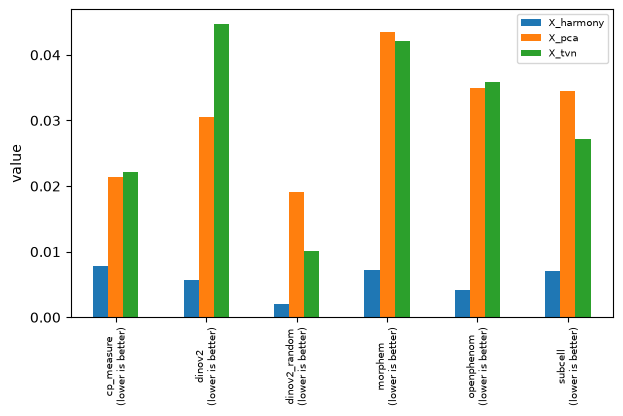

alignment,X_harmony,X_pca,X_tvn
model,,,
cp_measure,0.008,0.021,0.022
dinov2,0.006,0.030,0.045
dinov2_random,0.002,0.019,0.010
morphem,0.007,0.044,0.042
openphenom,0.004,0.035,0.036
subcell,0.007,0.034,0.027


In [9]:
# pl.metrics groups by "metric" and draws one bar per "representation", which here is one group per
# feature set and one bar per alignment.
mt.pl.metrics(
    comparison.rename(columns={"model": "metric", "alignment": "representation", "source variance": "value"}).assign(
        better="lower"
    )[["metric", "representation", "value", "better"]]
)
plt.show()
comparison.pivot(index="model", columns="alignment", values="source variance").round(3)

Harmony takes the laboratory down to a fraction of a percent on every feature set. TVN does not
consistently reduce it: it is unchanged on three blocks, up by half on DINOv2, and down on SubCell and the
untrained model. That is consistent with what the two do — Harmony mixes the batches in every local
neighbourhood, while TVN aligns each batch's control covariance to the pooled one — and a plausible reason the
two readouts disagree.

Read this together with the tables above, not instead of them. TVN leaves the laboratory in place and is still
the only alignment under which the embeddings' annotation recall clears its own null; Harmony removes it and is the only one under which most blocks
call many compounds. A correction that removes the batch may also have taken biology with it, and one that leaves it
may still help, so neither readout alone tells you which happened. Which alignment to use is a decision about
what the screen is for, not a default.

## What the leading components are

`pc_regression`, per component, on the cell count and on the laboratory.

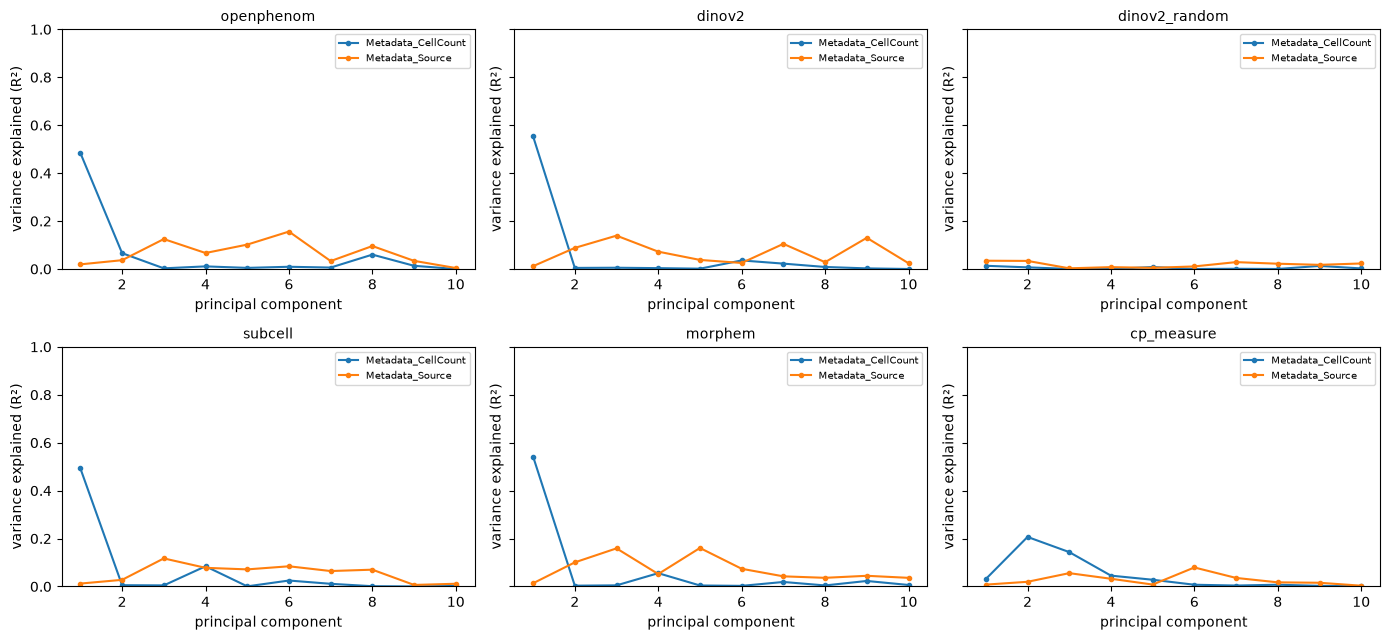

key,cell count,source,"first component, r with count"
openphenom,0.323,0.035,-0.696
dinov2,0.376,0.030,0.744
dinov2_random,0.015,0.019,-0.116
subcell,0.216,0.034,0.702
morphem,0.301,0.044,0.736
cp_measure,0.060,0.021,-0.176


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharey=True)
for ax, (model, wells) in zip(axes.ravel(), blocks.items(), strict=True):
    mt.pl.batch_variance(wells, keys=["Metadata_CellCount", "Metadata_Source"], use_rep="X_pca", n_comps=10, ax=ax)
    ax.set_title(model, fontsize=10)
fig.tight_layout()
plt.show()

variance = pd.concat(
    {
        model: mt.metrics.batch_variance_explained(
            wells, keys=["Metadata_CellCount", "Metadata_Source"], use_rep="X_pca"
        ).set_index("key")["value"]
        for model, wells in blocks.items()
    },
    axis=1,
).T.rename(columns={"Metadata_CellCount": "cell count", "Metadata_Source": "source"})
variance["first component, r with count"] = {
    model: float(np.corrcoef(wells.obsm["X_pca"][:, 0], wells.obs["Metadata_CellCount"])[0, 1])
    for model, wells in blocks.items()
}
variance.round(3)

On every trained embedding the first component correlates with the cell count at about 0.70 to 0.74 in
magnitude, against 0.18 for `cp_measure` and 0.12 for the untrained model, and over the fifty components the
count accounts for between six and twelve and a half times as much of the variance as the laboratory does. The
largest axis of these models tracks how full the well is. The untrained model does not do it, so the trained
models learned it; `cp_measure`, a per-cell measurement summarised over the well, does it far less.

The untreated control wells differ 1.7-fold in cell count between sites, as the
[dataset page](../../datasets/jump_lite.ipynb) shows. If a good part of what separates the laboratories is how
dense their wells are, a representation whose largest axis tracks density entangles the batch with the biology
on that axis, which would be one reason the embeddings need the correction more than `cp_measure` does. This
page does not test that.

## Is the hit a hit, or did the cells die?

This is the question a screener asks first, and on an embedding it is sharper than usual. Call hits, then ask
`tl.cytotoxicity` whether the compounds furthest from the controls are the ones that lost cells.

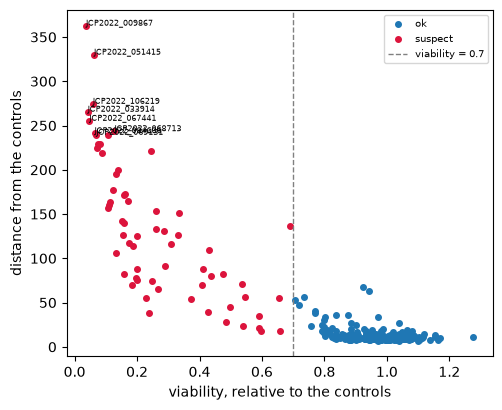

,"rho(distance, viability)",suspect,groups
model,,,
openphenom,-0.661,64,302
dinov2,-0.705,64,302
dinov2_random,-0.538,64,302
subcell,-0.736,64,302
morphem,-0.698,64,302
cp_measure,-0.700,64,302


In [11]:
toxicity = []
for model, wells in blocks.items():
    scratch = wells.copy()
    mt.tl.hit_calling(scratch, use_rep="X_pca", n_permutations=200, seed=0)
    mt.tl.cytotoxicity(scratch, site_key=None)  # one field per well, so there is no field count to divide by
    table = scratch.uns["mantispy"]["cytotoxicity"]
    toxicity.append(
        {
            "model": model,
            "rho(distance, viability)": float(table[["distance", "viability"]].corr(method="spearman").iloc[0, 1]),
            "suspect": int(table["suspect"].sum()),
            "groups": len(table),
        }
    )
    if model == "openphenom":
        mt.pl.cytotoxicity(scratch)
        plt.show()
pd.DataFrame(toxicity).set_index("model").round(3)

The `suspect` count is identical on every block, the untrained one included, so here it follows viability
alone. The rank correlation between distance and viability is negative on every block, from −0.54 for the
untrained model to −0.74 for SubCell, and `cp_measure` sits at −0.70, inside the range of the trained
embeddings. Cell loss moves a profile away from the controls whichever feature block measures it, because a
compound that kills cells has changed the well. The top of this screen's hit list is partly a cytotoxicity
ranking whichever block you use.

### Should the cell count be removed?

The reflex is to take the count out: drop the wells under a floor, or regress the count out of the profiles.
Both are measured here on OpenPhenom, against keeping every well.

In [12]:
def remedy(treatment):
    """The recipe `prepared` ran, with a cell-count floor or with the count regressed out."""
    if treatment == "none":
        return blocks["openphenom"]  # already built above; rebuilding it is how the two quietly diverge
    wells = mt.ds.jump_lite("openphenom")
    if treatment == "floor":
        wells = wells[wells.obs["Metadata_CellCount"].to_numpy(dtype=float) >= 50].copy()
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    # The same step `prepared` runs. It drops nothing from this embedding, and leaving it out is how the
    # floor and regress arms would end up compared against a "none" arm built a different way.
    mt.pp.feature_select(wells, operations=("drop_degenerate", "drop_na_columns"), na_cutoff=0.0)
    wells = mt.pp.subset_features(wells)
    if treatment == "regress":
        mt.pp.regress_out(wells, keys=("Metadata_CellCount",), by="Metadata_Plate")
    return align(wells)


remedies = []
for treatment in ("none", "floor", "regress"):
    trial = remedy(treatment)
    left = float(mt.metrics.pc_regression(trial, key="Metadata_CellCount", use_rep="X_pca")["value"].iloc[0])
    for rep in ("X_pca", "X_tvn", "X_harmony"):
        result = scored(treatment, trial, rep)
        remedies.append(
            {
                "treatment": treatment,
                "alignment": rep,
                "wells": trial.n_obs,
                "cell count variance": left,
                "mAP": result["mAP"],
                "significant": result["significant"],
                "target recall": result["target recall"],
                "recall null": result["recall null"],
                "recall p": result["recall p"],
            }
        )
pd.DataFrame(remedies).set_index(["treatment", "alignment"]).round(3)

wells  cell count variance    mAP  significant  \
treatment alignment                                                   
none      X_pca       1536                0.323  0.016            0   
          X_tvn       1536                0.323  0.018            3   
          X_harmony   1536                0.323  0.037            4   
floor     X_pca       1397                0.250  0.016            0   
          X_tvn       1397                0.250  0.020            3   
          X_harmony   1397                0.250  0.034           16   
regress   X_pca       1536                0.064  0.010            1   
          X_tvn       1536                0.064  0.018            3   
          X_harmony   1536                0.064  0.022            0   

                     target recall  recall null  recall p  
treatment alignment                                        
none      X_pca              0.057        0.066     0.851  
          X_tvn              0.127        0.091     0.010  
          X_harmony          0.067        0.081     0.970  
floor     X_pca              0.048        0.073     1.000  
          X_tvn              0.152        0.111     0.010  
          X_harmony          0.051        0.061     0.921  
regress   X_pca              0.127        0.093     0.010  
          X_tvn              0.161        0.114     0.010  
          X_harmony          0.109        0.086     0.010

Each remedy buys something the other does not. Regressing the count out takes its share of the variance from
0.32 to 0.06 and lifts annotation recall above its own null under every alignment, where keeping every well
clears it only under TVN. It costs retrieval: under Harmony the compounds called drop from four to none. The
floor discards 139 wells, raises the calls under Harmony from four to sixteen at a small cost in mAP, and leaves
recall below its null there. Under TVN neither costs anything this table scores.

In a compound screen the count is partly a treatment effect, since the compound reduced it, so regressing it
out removes part of the phenotype and not only a nuisance. The JUMP recipe regresses the cell count out of the
ORF and CRISPR arms and not out of compounds {cite:p}`Chandrasekaran_2023`. This page keeps every well and does
not regress; report the count beside the readouts instead.

## Summary

- On telling a compound from DMSO the blocks were close; on telling compounds apart across laboratories
  without a correction the embeddings called at most five compounds to `cp_measure`'s 32. Harmony narrowed that
  for every trained embedding but OpenPhenom.
- Read Harmony as a range over seeds, and read `cp_measure`'s row as one recipe: the rank transform halves its
  calls under Harmony.
- Measure chance with `known_relationships(n_permutations=...)`, and keep an untrained model in the comparison.
  Against a fixed 10% it would have looked like the best model without TVN.
- The trained embeddings' largest axis tracks confluence, and distance from the controls tracks cell loss on
  every block.
- The three alignments disagree and none dominates: Harmony lets the embeddings' compounds reproduce across
  sites, TVN lets their annotation recall clear its null.

All of it is for off-the-shelf embeddings on lossy JUMP images and one CellProfiler recipe.